In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from scipy.stats import randint, uniform
import time
from sklearn.pipeline import Pipeline

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

In [3]:
# Load a classification dataset
cancer = load_breast_cancer()
X_class = cancer.data
y_class = cancer.target

In [4]:
# Load a regression dataset
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target

In [5]:
# Split data into training and testing sets
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

In [6]:
# Standardize features
scaler = StandardScaler()
X_class_train_scaled = scaler.fit_transform(X_class_train)
X_class_test_scaled = scaler.transform(X_class_test)

In [7]:
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test)

# Part 1: Grid Search for SVM Classifier

In [8]:
# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

In [9]:
# Create SVM classifier
svm = SVC(random_state=42)

In [10]:
# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy',
    return_train_score=True
)

In [11]:
# Start timing
start_time = time.time()

In [12]:
# Fit GridSearchCV
grid_search.fit(X_class_train_scaled, y_class_train)

GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1],
                         'kernel': ['rbf', 'poly']},
             return_train_score=True, scoring='accuracy')

In [13]:
# End timing
grid_time = time.time() - start_time

In [14]:
# Print results
print(f"Grid Search completed in {grid_time:.2f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Grid Search completed in 9.31 seconds
Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.9736


In [15]:
# Evaluate on test set
y_pred = grid_search.predict(X_class_test_scaled)
grid_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {grid_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9825


In [16]:
# Visualization of Grid Search results
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_pivot = grid_results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

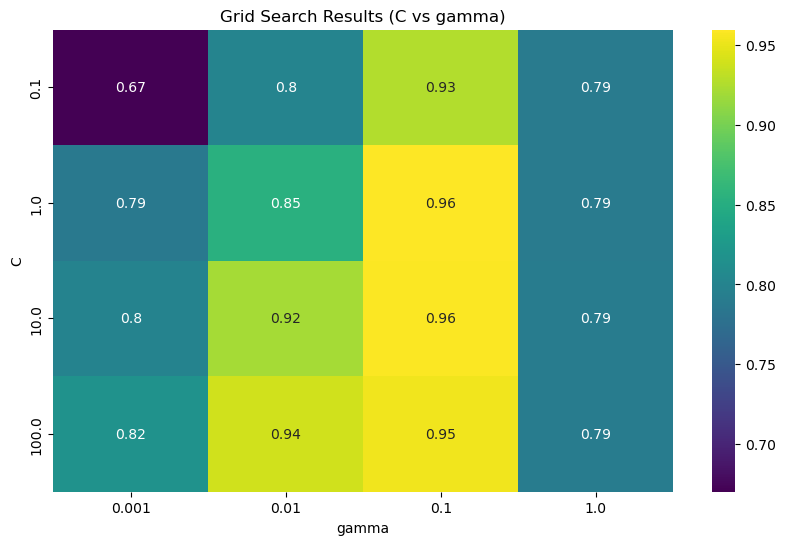

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(grid_pivot, annot=True, cmap='viridis')
plt.title('Grid Search Results (C vs gamma)')
plt.ylabel('C')
plt.xlabel('gamma')
plt.show()


# Part 2: Random Search for SVM Classifier

In [18]:
# Define the parameter distributions
param_dist = {
    'C': uniform(0.1, 100),
    'gamma': uniform(0.001, 1),
    'kernel': ['rbf', 'poly']
}


In [19]:
# Create RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [20]:
# Start timing
start_time = time.time()

In [21]:
# Fit RandomizedSearchCV
random_search.fit(X_class_train_scaled, y_class_train)

RandomizedSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000232C643D210>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000232C6550C90>,
                                        'kernel': ['rbf', 'poly']},
                   random_state=42, return_train_score=True,
                   scoring='accuracy')

In [22]:
# End timing
random_time = time.time() - start_time

In [23]:
# Print results
print(f"Random Search completed in {random_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_:.4f}")

Random Search completed in 0.46 seconds
Best parameters: {'C': 0.8066305219717406, 'gamma': 0.024062425041415758, 'kernel': 'rbf'}
Best cross-validation score: 0.9714


In [24]:
# Evaluate on test set
y_pred = random_search.predict(X_class_test_scaled)
random_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {random_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9649


In [25]:
# Compare Grid Search and Random Search
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy],
    'Execution Time (s)': [grid_time, random_time]
})

print("\nComparison of Grid Search and Random Search:")
print(results_comparison)


Comparison of Grid Search and Random Search:
          Method  Best CV Score  Test Accuracy  Execution Time (s)
0    Grid Search       0.973626       0.982456            9.308192
1  Random Search       0.971429       0.964912            0.462063


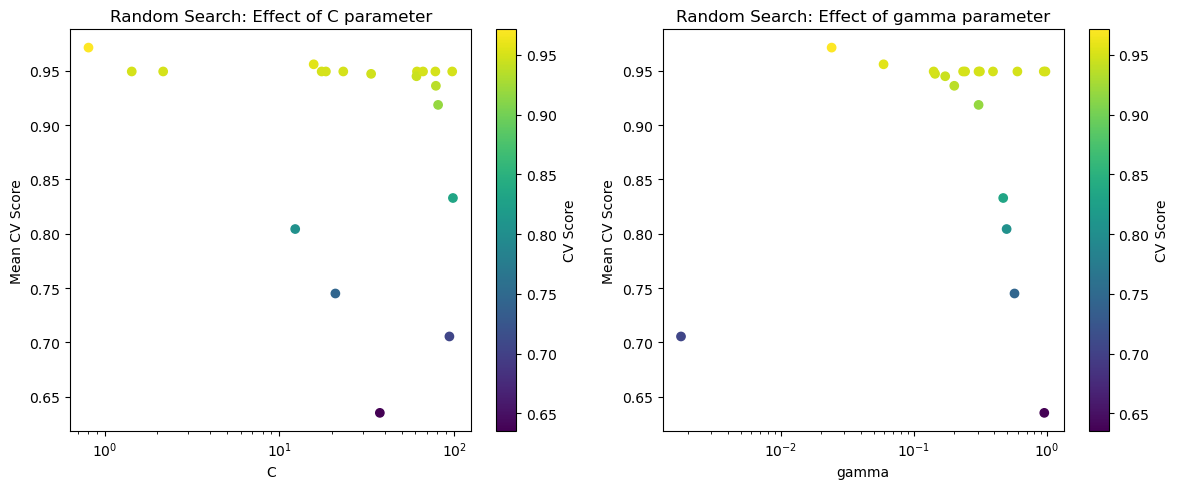

In [26]:
# Visualize random search results - plot parameter samples and their scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(random_search.cv_results_['param_C'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of C parameter')

plt.subplot(1, 2, 2)
plt.scatter(random_search.cv_results_['param_gamma'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of gamma parameter')
plt.tight_layout()
plt.show()

# Part 3: Bayesian Optimization using scikit-optimize (skopt)

In [27]:
# Install scikit-optimize if not already installed
!pip install scikit-optimize

In [28]:
import skopt
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [29]:
# Define the search space
search_spaces = {
    'C': Real(0.1, 100, prior='log-uniform'),
    'gamma': Real(0.001, 1.0, prior='log-uniform'),
    'kernel': Categorical(['rbf', 'poly'])
}

In [30]:
# Create BayesSearchCV object
bayes_search = BayesSearchCV(
    estimator=svm,
    search_spaces=search_spaces,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [31]:
# Start timing
start_time = time.time()

In [32]:
# Fit BayesSearchCV
bayes_search.fit(X_class_train_scaled, y_class_train)

BayesSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
              random_state=42, return_train_score=True, scoring='accuracy',
              search_spaces={'C': Real(low=0.1, high=100, prior='log-uniform', transform='normalize'),
                             'gamma': Real(low=0.001, high=1.0, prior='log-uniform', transform='normalize'),
                             'kernel': Categorical(categories=('rbf', 'poly'), prior=None)})

In [33]:
# End timing
bayes_time = time.time() - start_time

In [34]:
# Print results
print(f"Bayesian Optimization completed in {bayes_time:.2f} seconds")
print(f"Best parameters: {bayes_search.best_params_}")
print(f"Best cross-validation score: {bayes_search.best_score_:.4f}")

Bayesian Optimization completed in 7.47 seconds
Best parameters: OrderedDict([('C', 47.479208101330435), ('gamma', 0.01504196942703971), ('kernel', 'rbf')])
Best cross-validation score: 0.9626


In [35]:
# Evaluate on test set
y_pred = bayes_search.predict(X_class_test_scaled)
bayes_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {bayes_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9561


In [36]:
# Update comparison table
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search', 'Bayesian Optimization'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_, bayes_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy, bayes_accuracy],
    'Execution Time (s)': [grid_time, random_time, bayes_time]
})

print("\nComparison of all methods:")
print(results_comparison)


Comparison of all methods:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456            9.308192
1          Random Search       0.971429       0.964912            0.462063
2  Bayesian Optimization       0.962637       0.956140            7.473756


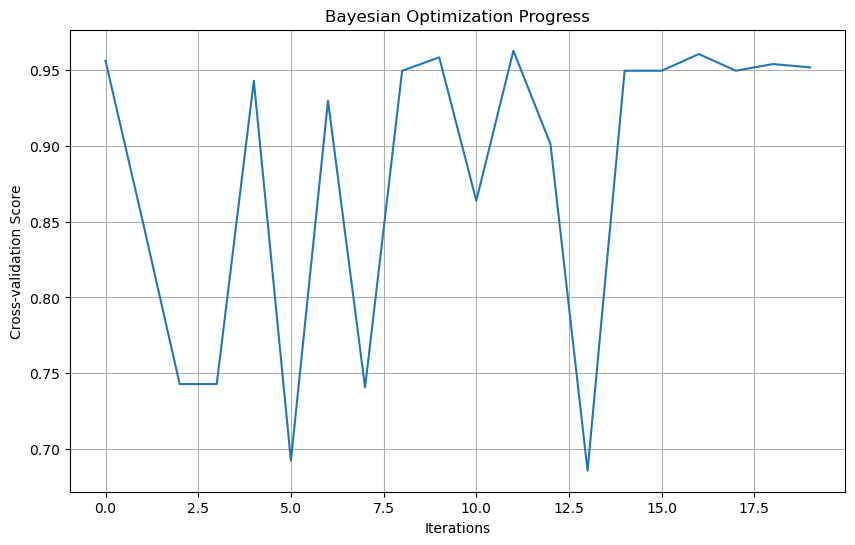

In [37]:
# Visualize Bayesian Optimization progress
plt.figure(figsize=(10, 6))
plt.plot(bayes_search.cv_results_['mean_test_score'])
plt.xlabel('Iterations')
plt.ylabel('Cross-validation Score')
plt.title('Bayesian Optimization Progress')
plt.grid(True)
plt.show()

# Part 4: Random Forest Regression with hyperparameter tuning

In [38]:
# Create a pipeline for regression
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [39]:
# Define parameter distributions for random search
rf_param_dist = {
    'regressor__n_estimators': randint(10, 200),
    'regressor__max_depth': randint(3, 20),
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 10),
    'regressor__max_features': ['auto', 'sqrt', 'log2', None]
}

In [40]:
# Create RandomizedSearchCV for regression
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='neg_mean_squared_error',
    return_train_score=True
)

In [41]:
# Start timing
start_time = time.time()

In [42]:
# Fit RandomizedSearchCV
rf_random_search.fit(X_reg_train, y_reg_train)

c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
15 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\base.py", line 1151, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HOME\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 420, in fit
    self._final_estimator.fit(Xt

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('regressor',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'regressor__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000232C6F4D510>,
                                        'regressor__max_features': ['auto',
                                                                    'sqrt',
                                                                    'log2',
                                                                    None],
                                        'regressor__min_sa...astructure.rv_discrete_frozen object at 0x00000232C734D610>,
                                        'regressor__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000232C7417550>,
                                        'regressor__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000232C6F4FC10>},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_squared_error')

In [43]:
# End timing
rf_random_time = time.time() - start_time

In [44]:
# Print results
print("\nRandom Forest Regression Hyperparameter Tuning Results:")
print(f"Random Search completed in {rf_random_time:.2f} seconds")
print(f"Best parameters: {rf_random_search.best_params_}")
print(f"Best cross-validation score (neg_mean_squared_error): {rf_random_search.best_score_:.4f}")


Random Forest Regression Hyperparameter Tuning Results:
Random Search completed in 4.13 seconds
Best parameters: {'regressor__max_depth': 18, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 8, 'regressor__min_samples_split': 15, 'regressor__n_estimators': 199}
Best cross-validation score (neg_mean_squared_error): -3316.3419


In [45]:
# Evaluate on test set
y_pred = rf_random_search.predict(X_reg_test)
mse = mean_squared_error(y_reg_test, y_pred)
r2 = r2_score(y_reg_test, y_pred)
print(f"Test MSE with optimal parameters: {mse:.4f}")
print(f"Test R² with optimal parameters: {r2:.4f}")

Test MSE with optimal parameters: 2808.9704
Test R² with optimal parameters: 0.4698


In [46]:
# Visualize feature importance from the best model
best_rf = rf_random_search.best_estimator_.named_steps['regressor']
feature_importance = best_rf.feature_importances_
feature_names = diabetes.feature_names

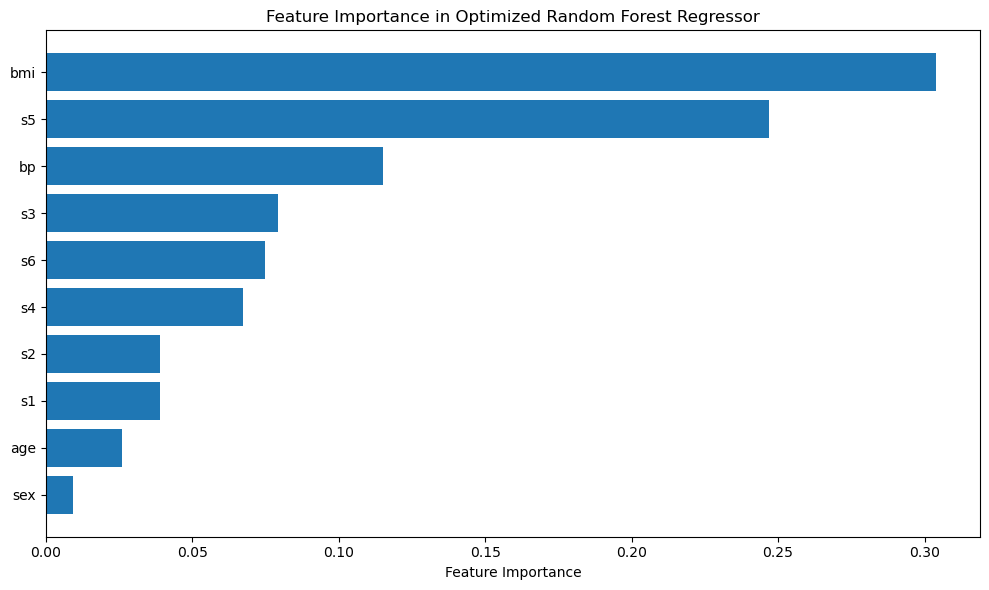

In [47]:
# Sort feature importances
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Optimized Random Forest Regressor')
plt.tight_layout()
plt.show()

# Part 5: Learning Curves for different hyperparameter settings

In [48]:
def plot_learning_curve(estimator, X, y, title, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

In [49]:
from sklearn.model_selection import learning_curve

In [50]:
# Plot learning curves for SVM with different hyperparameters
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

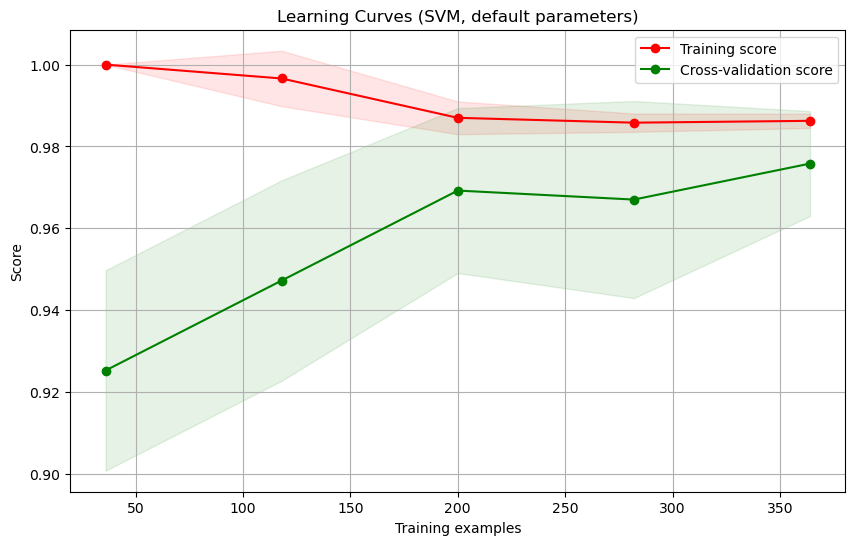

In [51]:
# Default parameters
svm_default = SVC(random_state=42)
plot_learning_curve(svm_default, X_class_train_scaled, y_class_train,
                   "Learning Curves (SVM, default parameters)")
plt.savefig('svm_default_learning_curve.png')

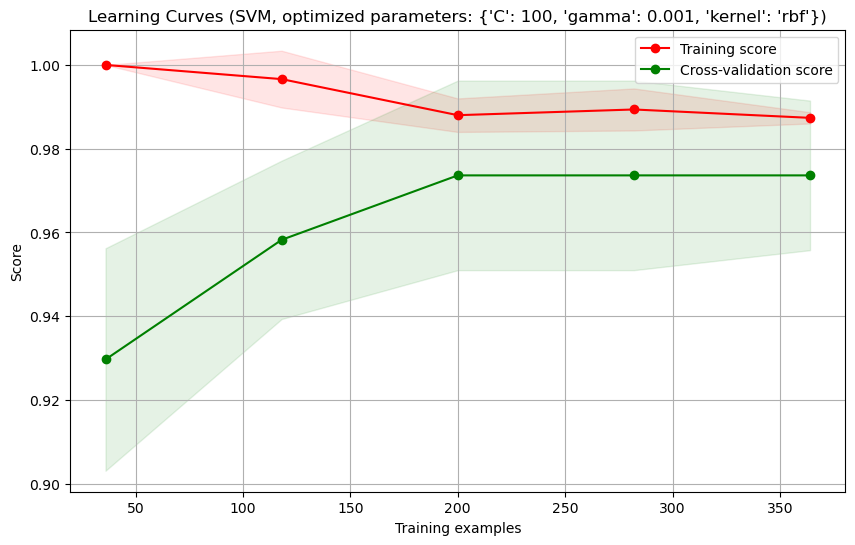

In [52]:
# Best parameters from grid search
svm_best = SVC(**grid_search.best_params_, random_state=42)
plot_learning_curve(svm_best, X_class_train_scaled, y_class_train,
                   f"Learning Curves (SVM, optimized parameters: {grid_search.best_params_})")
plt.savefig('svm_optimized_learning_curve.png')

# Part 6: Cross-validation visualization for different hyperparameters

In [53]:
# Function to run cross-validation with different hyperparameters and visualize results
def plot_cv_results(param_name, param_range, estimator, X, y, cv=5, scoring='accuracy'):
    cv_scores = []
    for param_value in param_range:
        params = {param_name: param_value}
        estimator.set_params(**params)
        scores = cross_val_score(estimator, X, y, cv=cv, scoring=scoring)
        cv_scores.append((param_value, np.mean(scores), np.std(scores)))

    cv_df = pd.DataFrame(cv_scores, columns=[param_name, 'Mean Score', 'Std Dev'])

    plt.figure(figsize=(10, 6))
    plt.errorbar(cv_df[param_name], cv_df['Mean Score'], yerr=cv_df['Std Dev'], marker='o')
    plt.title(f'Cross-validation scores for different {param_name} values')
    plt.xlabel(param_name)
    plt.ylabel('Mean CV Score')
    plt.grid(True)
    if param_name in ['C', 'gamma']:
        plt.xscale('log')
    return cv_df

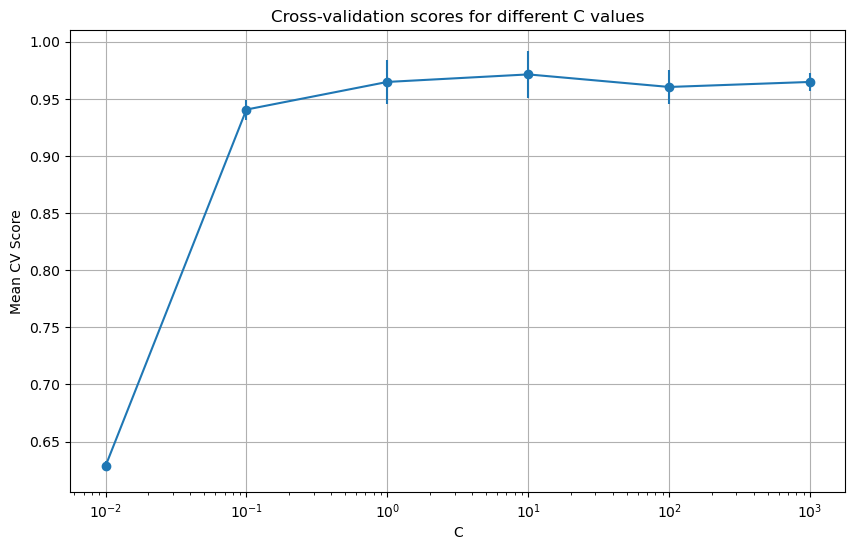

In [54]:
# Run CV visualization for C parameter
svm_model = SVC(kernel='rbf', gamma=0.01, random_state=42)
C_range = [0.01, 0.1, 1, 10, 100, 1000]
cv_results_C = plot_cv_results('C', C_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

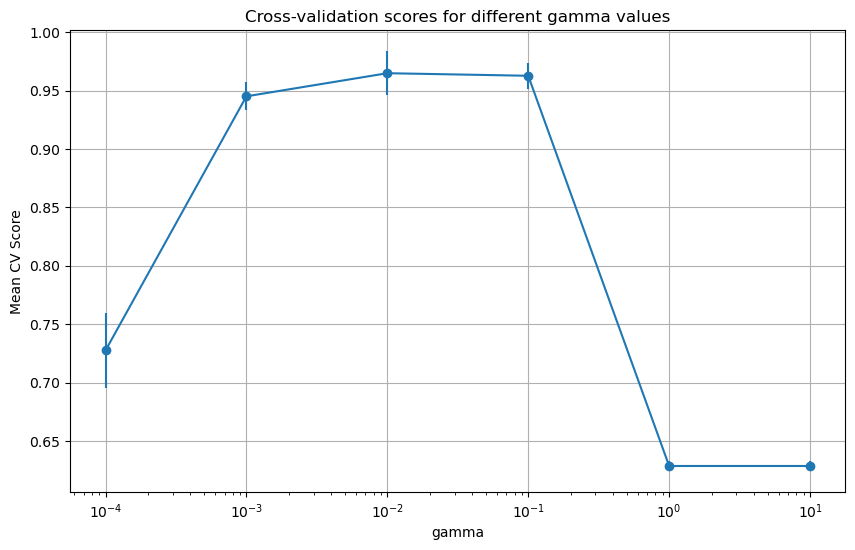

In [55]:
# Run CV visualization for gamma parameter
svm_model = SVC(kernel='rbf', C=1, random_state=42)
gamma_range = [0.0001, 0.001, 0.01, 0.1, 1, 10]
cv_results_gamma = plot_cv_results('gamma', gamma_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

# Part 7: Combining Grid Search and Random Search strategies

In [56]:
# Define a smaller search space for initial grid search
coarse_param_grid = {
    'C': [0.1, 10, 1000],
    'gamma': [0.001, 0.1, 10],
    'kernel': ['rbf', 'poly']
}

In [57]:
# Create GridSearchCV object for coarse search
coarse_grid_search = GridSearchCV(
    estimator=svm,
    param_grid=coarse_param_grid,
    cv=3,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy'
)


In [58]:
# Perform coarse grid search
coarse_grid_search.fit(X_class_train_scaled, y_class_train)
best_C = coarse_grid_search.best_params_['C']
best_gamma = coarse_grid_search.best_params_['gamma']
best_kernel = coarse_grid_search.best_params_['kernel']

print(f"Coarse grid search best parameters: C={best_C}, gamma={best_gamma}, kernel={best_kernel}")


Coarse grid search best parameters: C=10, gamma=0.001, kernel=rbf


In [59]:
# Define refined search space around the best parameters
if best_kernel == 'rbf':
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['rbf']
    }
else:
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['poly'],
        'degree': [2, 3, 4, 5]
    }

In [60]:
# Create RandomizedSearchCV object for refined search
refined_random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=refined_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy'
)

In [61]:
# Perform refined random search
refined_random_search.fit(X_class_train_scaled, y_class_train)

RandomizedSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000232C64F2150>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000232C73DBC50>,
                                        'kernel': ['rbf']},
                   random_state=42, scoring='accuracy')

In [62]:
print(f"Refined random search best parameters: {refined_random_search.best_params_}")
print(f"Refined random search best score: {refined_random_search.best_score_:.4f}")

Refined random search best parameters: {'C': 21.55967889037648, 'gamma': 0.0008449057043952079, 'kernel': 'rbf'}
Refined random search best score: 0.9780


In [63]:
# Evaluate on test set
y_pred = refined_random_search.predict(X_class_test_scaled)
refined_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {refined_accuracy:.4f}")


Test accuracy with optimal parameters: 0.9825


In [64]:
# Update comparison table
results_comparison['Method'] = pd.Categorical(
    results_comparison['Method'],
    categories=['Grid Search', 'Random Search', 'Bayesian Optimization', 'Combined Approach'],
    ordered=True
)


In [65]:
combined_approach = pd.DataFrame({
    'Method': ['Combined Approach'],
    'Best CV Score': [refined_random_search.best_score_],
    'Test Accuracy': [refined_accuracy],
    'Execution Time (s)': [None]  # We didn't time this approach
})

In [66]:
results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)
print("\nComparison of all methods including combined approach:")
print(results_comparison)


Comparison of all methods including combined approach:
                  Method  Best CV Score  Test Accuracy Execution Time (s)
0            Grid Search       0.973626       0.982456           9.308192
1          Random Search       0.971429       0.964912           0.462063
2  Bayesian Optimization       0.962637       0.956140           7.473756
3      Combined Approach       0.978022       0.982456               None


# Part 8: Visualizing hyperparameter importance

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [68]:
# Train a model with the best parameters from Bayesian search
best_svm = SVC(**bayes_search.best_params_, random_state=42, probability=True)
best_svm.fit(X_class_train_scaled, y_class_train)

SVC(C=47.479208101330435, gamma=0.01504196942703971, probability=True,
    random_state=42)

In [69]:
# Create a dataset of different hyperparameter configurations and their performance
hyperparam_data = []
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    score = grid_search.cv_results_['mean_test_score'][i]

    # Encode the kernel
    kernel_rbf = 1 if params['kernel'] == 'rbf' else 0
    kernel_poly = 1 if params['kernel'] == 'poly' else 0

    hyperparam_data.append([params['C'], params['gamma'], kernel_rbf, kernel_poly, score])

hyperparam_df = pd.DataFrame(hyperparam_data,
                             columns=['C', 'gamma', 'kernel_rbf', 'kernel_poly', 'score'])

In [70]:
# Train a random forest to predict model performance based on hyperparameters
X_hyperparam = hyperparam_df.iloc[:, :-1].values
y_hyperparam = hyperparam_df.iloc[:, -1].values

rf_importance = RandomForestRegressor(n_estimators=100, random_state=42)
rf_importance.fit(X_hyperparam, y_hyperparam)

RandomForestRegressor(random_state=42)

In [71]:
# Get feature importances
importances = rf_importance.feature_importances_
feature_names = ['C', 'gamma', 'kernel_rbf', 'kernel_poly']

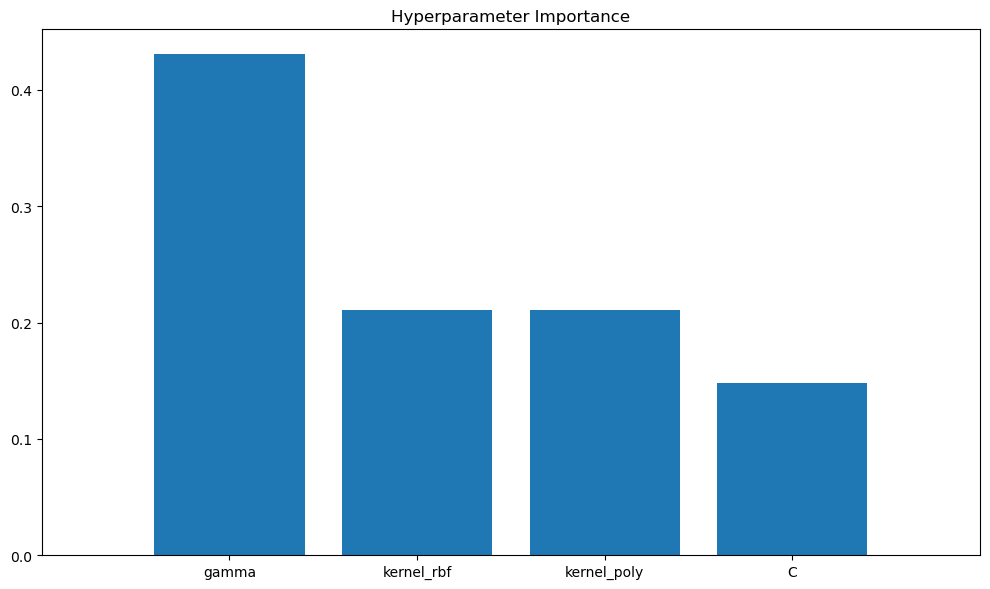

In [72]:
# Plot feature importances
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
plt.title('Hyperparameter Importance')
plt.bar(range(X_hyperparam.shape[1]), importances[indices], align='center')
plt.xticks(range(X_hyperparam.shape[1]), [feature_names[i] for i in indices])
plt.xlim([-1, X_hyperparam.shape[1]])
plt.tight_layout()
plt.show()

In [73]:
# Calculate permutation importances as an alternative measure
perm_importance = permutation_importance(rf_importance, X_hyperparam, y_hyperparam,
                                         n_repeats=10, random_state=42)

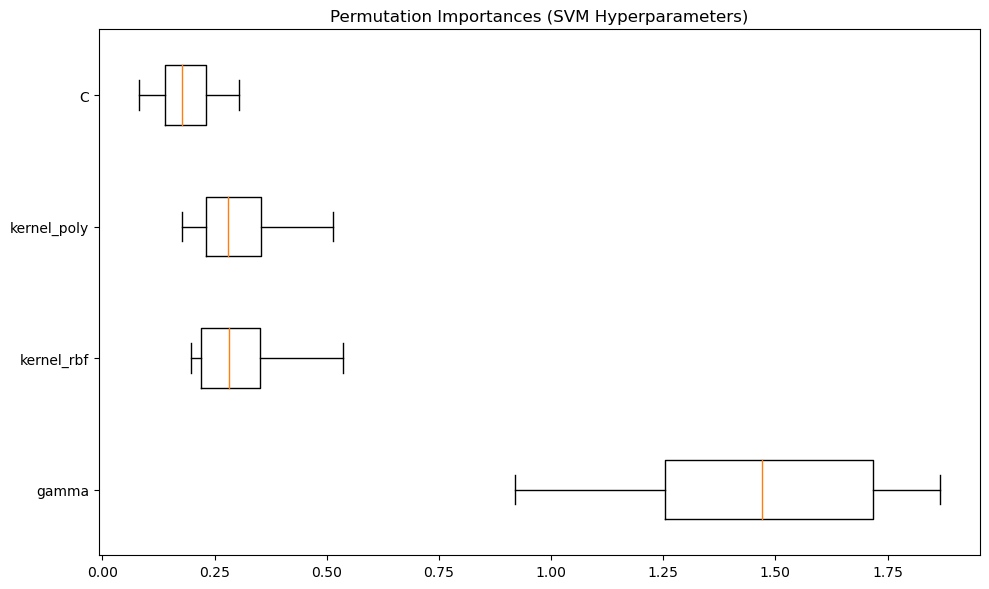

In [74]:
# Plot permutation importances
plt.figure(figsize=(10, 6))
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,
            labels=[feature_names[i] for i in sorted_idx])
plt.title("Permutation Importances (SVM Hyperparameters)")
plt.tight_layout()
plt.show()

# Exercise

In [75]:
# Student Exercise: Multi-Model Hyperparameter Optimization Challenge
# Time Estimate: 3-4 hours

# ==============================================================================
# INTRODUCTION
# ==============================================================================
# In this exercise, you'll implement and compare different hyperparameter tuning
# techniques across multiple models on a real-world dataset. You'll evaluate model
# performance, analyze the efficiency of various tuning methods, and build a meta-model
# to predict which algorithm performs best based on dataset characteristics.


In [76]:
# ==============================================================================
# PART 1: SETUP AND DATA PREPARATION
# ==============================================================================
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import time

# Load the California housing dataset
# This dataset contains information about housing in California
# with features like median income, house age, average rooms, etc.
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

# TODO: Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Ridge Regression
RMSE: 0.7205 ± 0.0103
R²:   0.6115 ± 0.0065

SVR
RMSE: 0.5931 ± 0.0106
R²:   0.7368 ± 0.0048

Random Forest
RMSE: 0.5115 ± 0.0044
R²:   0.8042 ± 0.0053

Gradient Boosting
RMSE: 0.5340 ± 0.0071
R²:   0.7866 ± 0.0032
               Model  RMSE Mean  RMSE Std   R2 Mean    R2 Std
0   Ridge Regression   0.720527  0.010280  0.611484  0.006460
1                SVR   0.593060  0.010571  0.736811  0.004813
2      Random Forest   0.511458  0.004399  0.804169  0.005324
3  Gradient Boosting   0.534012  0.007127  0.786592  0.003211


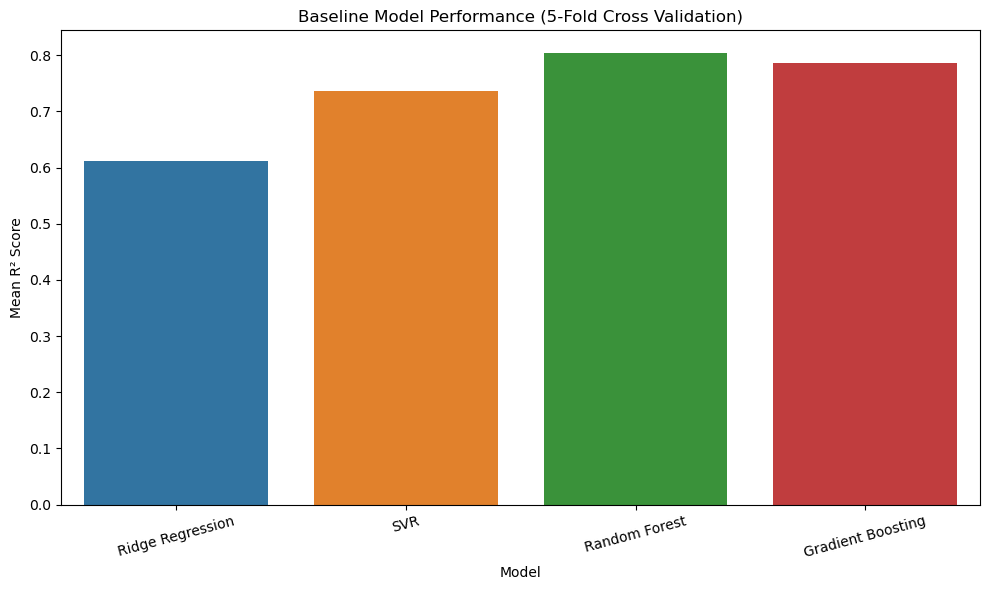

In [77]:
# ==============================================================================
# PART 2: BASELINE MODELS
# ==============================================================================
# Import models
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# TODO: Create a dictionary of baseline models with default parameters
# Include Ridge Regression, SVR, Random Forest, and Gradient Boosting
models = {
    "Ridge Regression": Ridge(),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# TODO: Evaluate baseline models using 5-fold cross-validation
# Calculate and print mean and std of RMSE and R² for each model
results = []

for name, model in models.items():
    # Cross-validation RMSE
    rmse_scores = -cross_val_score(model,X_train_scaled,y_train,cv=5,scoring='neg_root_mean_squared_error')

    # Cross-validation R²
    r2_scores = cross_val_score(model,X_train_scaled,y_train,cv=5,scoring='r2')

    results.append({
        'Model': name,
        'RMSE Mean': rmse_scores.mean(),
        'RMSE Std': rmse_scores.std(),
        'R2 Mean': r2_scores.mean(),
        'R2 Std': r2_scores.std()})

    print(f"\n{name}")
    print(f"RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
    print(f"R²:   {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

results_df = pd.DataFrame(results)
print(results_df)

# TODO: Visualize baseline model performance with a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Model',y='R2 Mean',data=results_df)

plt.title('Baseline Model Performance (5-Fold Cross Validation)')
plt.ylabel('Mean R² Score')
plt.xlabel('Model')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


Tuning Ridge Regression...
Best Parameters: {'alpha': 0.01}
Best CV R²: 0.6115
Time Taken: 6.06 seconds

Tuning SVR...
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV R²: 0.7583
Time Taken: 273.03 seconds

Tuning Random Forest...
Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²: 0.8051
Time Taken: 465.24 seconds

Tuning Gradient Boosting...
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV R²: 0.8312
Time Taken: 117.84 seconds

Grid Search Results
               Model  Best R2 Score  Time (seconds)  \
0   Ridge Regression       0.611484        6.058361   
1                SVR       0.758331      273.030139   
2      Random Forest       0.805062      465.243288   
3  Gradient Boosting       0.831167      117.844375   

                                     Best Parameters  
0                                    {'alpha': 0.01}  
1       {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}  
2  {'ma

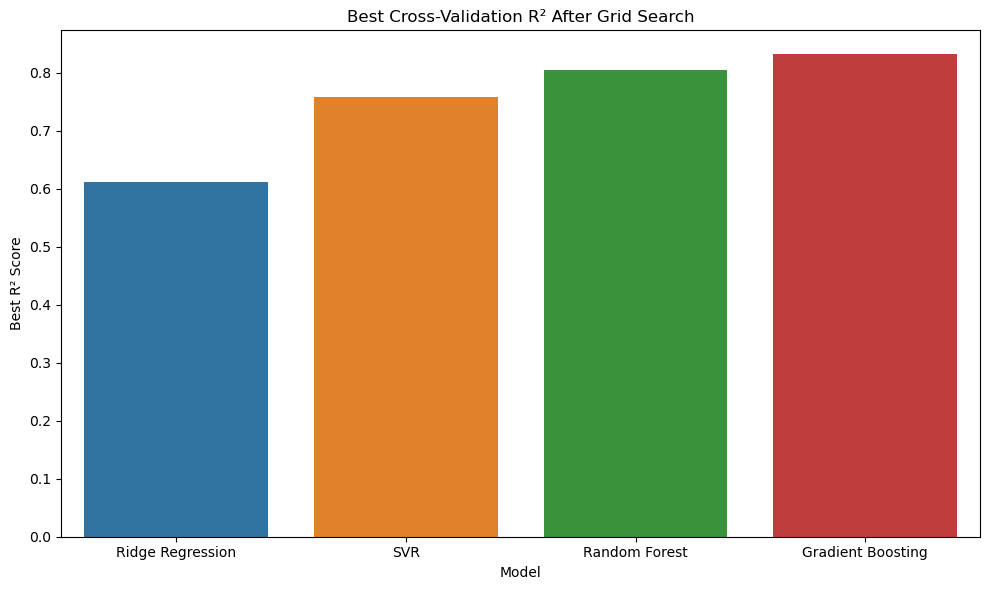

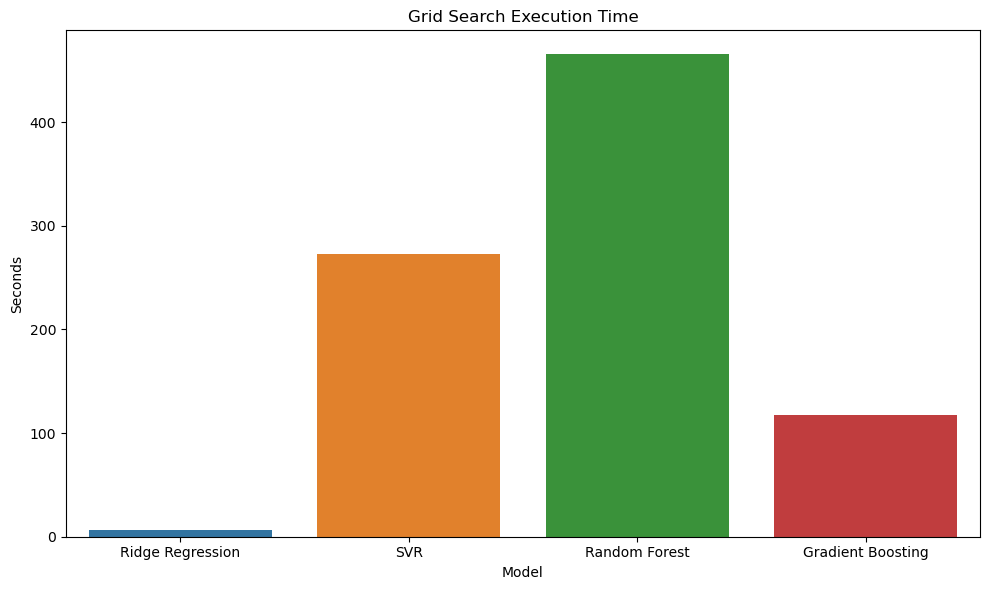

In [78]:
# ==============================================================================
# PART 3: HYPERPARAMETER TUNING USING GRID SEARCH
# ==============================================================================
from sklearn.model_selection import GridSearchCV

# TODO: Define parameter grids for each model
# Ridge: alpha values
# SVR: C, gamma, and kernel values
# Random Forest: n_estimators, max_depth, min_samples_split
# Gradient Boosting: n_estimators, max_depth, learning_rate
param_grids = {
    "Ridge Regression": {"alpha": [0.01, 0.1, 1, 10, 100]},
    "SVR": {"C": [0.1, 1, 10],"gamma": ["scale", "auto"],"kernel": ["rbf", "linear"]},
    "Random Forest": {"n_estimators": [100, 200],"max_depth": [None, 10, 20],"min_samples_split": [2, 5]},
    "Gradient Boosting": {"n_estimators": [100, 200],"max_depth": [3, 5],"learning_rate": [0.01, 0.1]}
}

# TODO: Create a function that performs grid search for a given model and parameter grid
# The function should return the best model, best parameters, best score, and elapsed time
def perform_grid_search(model, param_grid, X_train, y_train):
    start_time = time.time()

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1)

    grid.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    return (
        grid.best_estimator_,
        grid.best_params_,
        grid.best_score_,
        elapsed_time
    )

# TODO: Apply grid search to all models
best_models = {}
tuning_results = []

for name, model in models.items():
    print(f"\nTuning {name}...")
    best_model, best_params, best_score, elapsed_time = perform_grid_search(model,param_grids[name],X_train_scaled,y_train)
    best_models[name] = best_model

    tuning_results.append({
        "Model": name,
        "Best R2 Score": best_score,
        "Time (seconds)": elapsed_time,
        "Best Parameters": str(best_params)
    })

    print("Best Parameters:", best_params)
    print("Best CV R²:", round(best_score, 4))
    print("Time Taken:", round(elapsed_time, 2), "seconds")

# TODO: Create a comparison table or visualization of grid search results
results_tuning_df = pd.DataFrame(tuning_results)
print("\nGrid Search Results")
print(results_tuning_df)
# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=results_tuning_df,x="Model",y="Best R2 Score")
plt.title("Best Cross-Validation R² After Grid Search")
plt.ylabel("Best R² Score")
plt.xlabel("Model")
plt.tight_layout()
plt.show()
print("\n")
# Visualization training time
plt.figure(figsize=(10, 6))
sns.barplot(data=results_tuning_df,x="Model",y="Time (seconds)")
plt.title("Grid Search Execution Time")
plt.ylabel("Seconds")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

               Model  Best R2 Score  \
0   Ridge Regression       0.611484   
1                SVR       0.770261   
2      Random Forest       0.804356   
3  Gradient Boosting       0.836986   

                                     Best Parameters  
0                      {'alpha': 2.0684494295802445}  
1  {'C': 6.942330265121568, 'gamma': 0.4411524937...  
2  {'max_depth': 16, 'min_samples_split': 3, 'n_e...  
3  {'learning_rate': 0.1012726728878613, 'max_dep...  


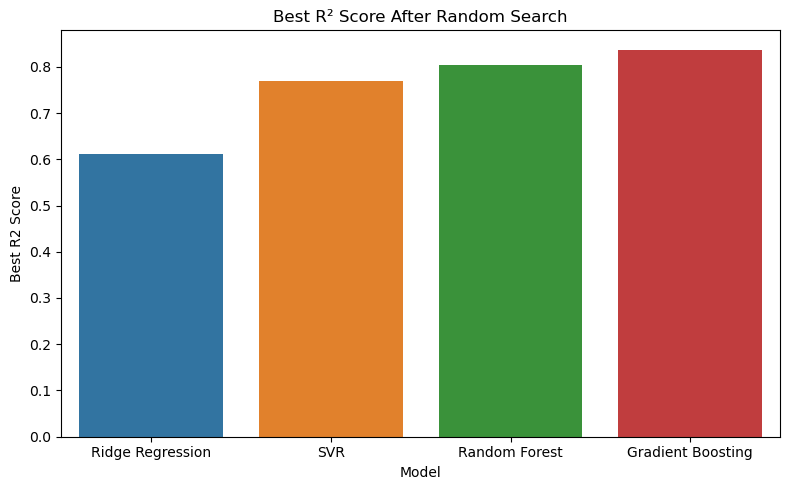

In [79]:
# ==============================================================================
# PART 4: HYPERPARAMETER TUNING USING RANDOM SEARCH
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# TODO: Define parameter distributions for each model
# Ridge: alpha values
# SVR: C, gamma values
# Random Forest: n_estimators, max_depth, min_samples_split
# Gradient Boosting: n_estimators, max_depth, learning_rate
param_distributions = {
    "Ridge Regression": {"alpha": uniform(0.01, 100) },
    "SVR": {"C": uniform(0.1, 10),"gamma": uniform(0.001, 1)},
    "Random Forest": {"n_estimators": randint(50, 300),"max_depth": randint(3, 20),"min_samples_split": randint(2, 10)},
    "Gradient Boosting": {"n_estimators": randint(50, 300),"max_depth": randint(2, 10),"learning_rate": uniform(0.01, 0.3)}
}
# TODO: Create a function that performs random search for a given model and parameter distribution
# The function should return the best model, best parameters, best score, and elapsed time
def perform_random_search(model, param_dist):
    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=20,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        random_state=42)
    random_search.fit(X_train_scaled, y_train)
    return (
        random_search.best_estimator_,
        random_search.best_params_,
        random_search.best_score_)

# TODO: Apply random search to all models with 20 iterations
results_random = []
for name, model in models.items():
    best_model, best_params, best_score = perform_random_search(
        model,
        param_distributions[name])
    results_random.append({
        "Model": name,
        "Best R2 Score": best_score,
        "Best Parameters": best_params})
results_random_df = pd.DataFrame(results_random)
print(results_random_df)

# TODO: Create a comparison table or visualization of random search results
plt.figure(figsize=(8, 5))
sns.barplot(
    data=results_random_df,
    x="Model",
    y="Best R2 Score")
plt.title("Best R² Score After Random Search")
plt.tight_layout()
plt.show()


               Model  Best R2 Score  \
0   Ridge Regression       0.611484   
1                SVR       0.747592   
2      Random Forest       0.805483   
3  Gradient Boosting       0.837759   

                                     Best Parameters  
0                      {'alpha': 0.3729944224017752}  
1  {'C': 41.601819921794664, 'gamma': 0.647680086...  
2  {'max_depth': 20, 'min_samples_split': 2, 'n_e...  
3  {'learning_rate': 0.09167861803544326, 'max_de...  


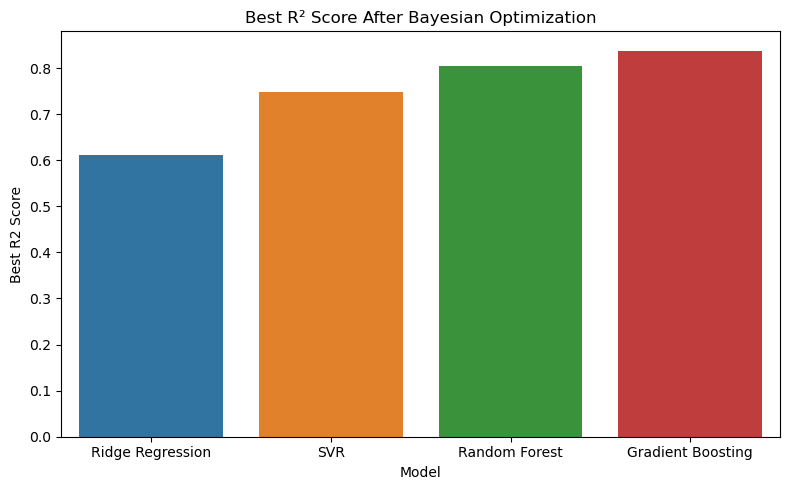

In [80]:
#==============================================================================
# PART 5: HYPERPARAMETER TUNING USING BAYESIAN OPTIMIZATION
# ==============================================================================

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# TODO: Define search spaces for each model using skopt's parameter types
search_spaces = {
    "Ridge Regression": {"alpha": Real(0.01, 100.0)},
    "SVR": {"C": Real(0.1, 100.0),"gamma": Real(0.0001, 1.0),"kernel": Categorical(["rbf", "linear"])},
    "Random Forest": {"n_estimators": Integer(50, 300),"max_depth": Integer(3, 20),"min_samples_split": Integer(2, 10)},
    "Gradient Boosting": {"n_estimators": Integer(50, 300),"max_depth": Integer(2, 10),"learning_rate": Real(0.01, 0.3)}
}
# TODO: Create a function that performs Bayesian optimization for a given model and search space
# The function should return the best model, best parameters, best score, and elapsed time
def perform_bayes_search(model, search_space):
    bayes_search = BayesSearchCV(
        estimator=model,
        search_spaces=search_space,
        n_iter=20,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        random_state=42)
    bayes_search.fit(X_train_scaled, y_train)
    return (
        bayes_search.best_estimator_,
        bayes_search.best_params_,
        bayes_search.best_score_)
# TODO: Apply Bayesian optimization to all models with 20 iterations
results_bayes = []
for name, model in models.items():
    best_model, best_params, best_score = perform_bayes_search(
        model,
        search_spaces[name])
    results_bayes.append({
        "Model": name,
        "Best R2 Score": best_score,
        "Best Parameters": best_params})
results_bayes_df = pd.DataFrame(results_bayes)
print(results_bayes_df)
# TODO: Create a comparison table or visualization of Bayesian optimization results
plt.figure(figsize=(8, 5))
sns.barplot(
    data=results_bayes_df,
    x="Model",
    y="Best R2 Score")
plt.title("Best R² Score After Bayesian Optimization")
plt.tight_layout()
plt.show()

               Model  Baseline  Grid Search  Random Search  Bayesian  \
0   Ridge Regression  0.611484     0.611484       0.611484  0.611484   
1                SVR  0.736811     0.758331       0.770261  0.747592   
2      Random Forest  0.804169     0.805062       0.804356  0.805483   
3  Gradient Boosting  0.786592     0.831167       0.836986  0.837759   

   Grid Improvement  Random Improvement  Bayesian Improvement  
0      1.109473e-07       -3.557265e-07          9.477533e-08  
1      2.151994e-02        3.344945e-02          1.078082e-02  
2      8.928352e-04        1.870330e-04          1.314217e-03  
3      4.457487e-02        5.039360e-02          5.116697e-02  


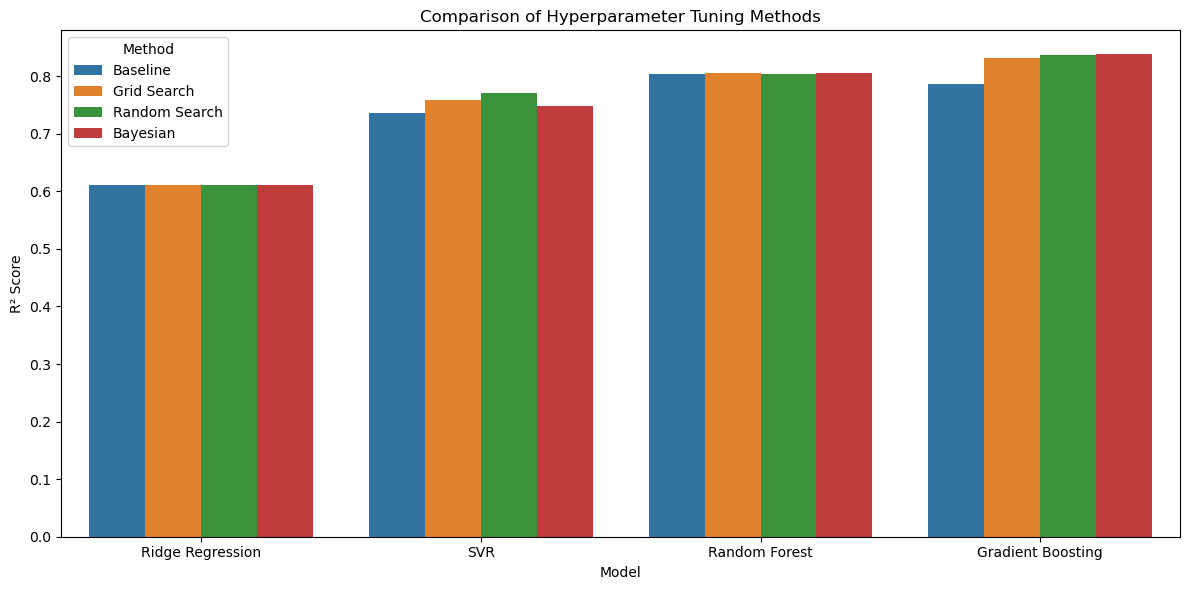

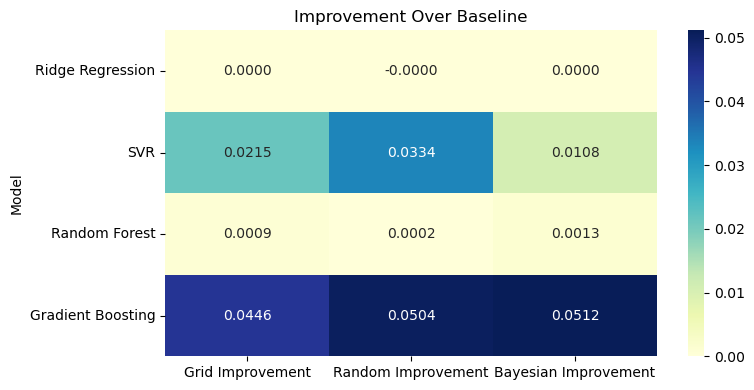

In [81]:
# ==============================================================================
# PART 6: COMPARISON OF TUNING METHODS
# ==============================================================================

# TODO: Create a comprehensive comparison of all tuning methods
# Include metrics like best score, elapsed time, and improvement over baseline
comparison_df = pd.DataFrame({
    "Model": results_df["Model"],
    "Baseline": results_df["R2 Mean"],
    "Grid Search": results_tuning_df["Best R2 Score"],
    "Random Search": results_random_df["Best R2 Score"],
    "Bayesian": results_bayes_df["Best R2 Score"]})
comparison_df["Grid Improvement"] = (comparison_df["Grid Search"] - comparison_df["Baseline"])
comparison_df["Random Improvement"] = (comparison_df["Random Search"] - comparison_df["Baseline"])
comparison_df["Bayesian Improvement"] = (comparison_df["Bayesian"] - comparison_df["Baseline"])
print(comparison_df)

# TODO: Visualize the comparison results
# Consider bar plots, scatter plots or heatmaps
#Barplot
comparison_long = comparison_df.melt(
    id_vars="Model",
    value_vars=["Baseline", "Grid Search", "Random Search", "Bayesian"],
    var_name="Method",
    value_name="R2 Score")
plt.figure(figsize=(12,6))
sns.barplot(
    data=comparison_long,
    x="Model",
    y="R2 Score",
    hue="Method")
plt.title("Comparison of Hyperparameter Tuning Methods")
plt.ylabel("R² Score")
plt.tight_layout()
plt.show()
#Heatmap
improvement_df = comparison_df.set_index("Model")[
    ["Grid Improvement",
     "Random Improvement",
     "Bayesian Improvement"]]
plt.figure(figsize=(8,4))
sns.heatmap(
    improvement_df,
    annot=True,
    cmap="YlGnBu",
    fmt=".4f")
plt.title("Improvement Over Baseline")
plt.tight_layout()
plt.show()

               Model   Improvement        Time    Efficiency
0   Ridge Regression  1.109473e-07    6.058361  1.831308e-08
1                SVR  2.151994e-02  273.030139  7.881892e-05
2      Random Forest  8.928352e-04  465.243288  1.919072e-06
3  Gradient Boosting  4.457487e-02  117.844375  3.782520e-04


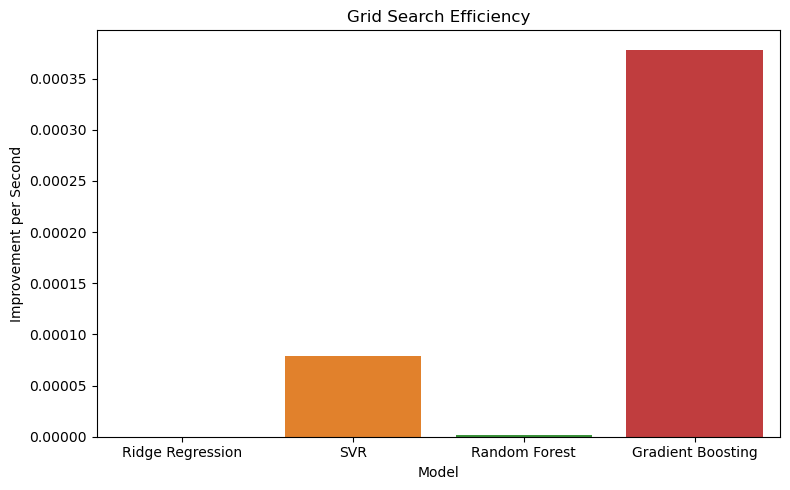

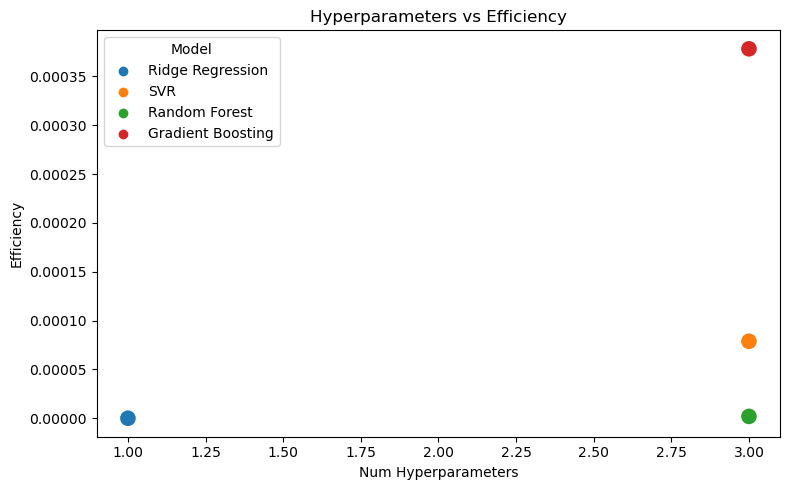

   n_samples  n_features  mean_value   std_value     best_algorithm
0       2000           8  171.220336  608.347410  Gradient Boosting
1       2000           8  166.850837  579.602313  Gradient Boosting
2       2000           8  175.170317  693.227027  Gradient Boosting
3       2000           8  173.768228  630.419834  Gradient Boosting
4       2000           8  171.957684  623.237020  Gradient Boosting
Meta-Learning Accuracy: 1.0


In [84]:
# ==============================================================================
# PART 7: ANALYZE TUNING EFFICIENCY AND META-LEARNING
# ==============================================================================

# TODO: Calculate efficiency metrics for each tuning method
# Efficiency = (improvement in score) / (time spent tuning)
efficiency_df = pd.DataFrame({
    "Model": comparison_df["Model"],
    "Improvement": comparison_df["Grid Improvement"],
    "Time": results_tuning_df["Time (seconds)"]
})

efficiency_df["Efficiency"] = (
    efficiency_df["Improvement"] /
    efficiency_df["Time"]
)

print(efficiency_df)

plt.figure(figsize=(8,5))
sns.barplot(
    data=efficiency_df,
    x="Model",
    y="Efficiency"
)
plt.title("Grid Search Efficiency")
plt.ylabel("Improvement per Second")
plt.tight_layout()
plt.show()

# TODO: Analyze the relationship between number of hyperparameters and tuning efficiency
hyperparameter_counts = {
    "Ridge Regression": 1,
    "SVR": 3,
    "Random Forest": 3,
    "Gradient Boosting": 3
}

efficiency_df["Num Hyperparameters"] = [
    hyperparameter_counts[m]
    for m in efficiency_df["Model"]
]

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=efficiency_df,
    x="Num Hyperparameters",
    y="Efficiency",
    hue="Model",
    s=150
)
plt.title("Hyperparameters vs Efficiency")
plt.tight_layout()
plt.show()

# Meta-learning: Predict which algorithm performs best based on a subset of data
# TODO: Create a function to extract dataset characteristics
# Examples: number of instances, number of features, feature statistics, etc.
def extract_dataset_characteristics(X):
    return {
        "n_samples": X.shape[0],
        "n_features": X.shape[1],
        "mean_value": np.mean(X),
        "std_value": np.std(X)}

# TODO: Generate multiple small datasets by sampling from the California housing data
# Extract characteristics and record best algorithm for each sample
meta_data = []

for i in range(20):
    sample_idx = np.random.choice(len(X),size=2000,replace=False)
    X_sample = X[sample_idx]
    y_sample = y[sample_idx]
    characteristics = extract_dataset_characteristics(X_sample)

    scores = {}

    for name, model in models.items():
        score = cross_val_score(model,X_sample,y_sample,cv=3,scoring="r2").mean()
        scores[name] = score
    best_algorithm = max(scores, key=scores.get)
    characteristics["best_algorithm"] = best_algorithm
    meta_data.append(characteristics)
meta_df = pd.DataFrame(meta_data)

print(meta_df.head())

# TODO: Train a classifier to predict the best algorithm based on dataset characteristics
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

le = LabelEncoder()
meta_df["best_algorithm"] = le.fit_transform(meta_df["best_algorithm"])

X_meta = meta_df.drop("best_algorithm", axis=1)
y_meta = meta_df["best_algorithm"]
X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(X_meta,y_meta,test_size=0.2,random_state=42)

meta_model = RandomForestClassifier(random_state=42)
meta_model.fit(X_train_meta, y_train_meta)
predictions = meta_model.predict(X_test_meta)

print("Meta-Learning Accuracy:",accuracy_score(y_test_meta, predictions))


               Model      RMSE        R2
0   Ridge Regression  0.745581  0.575788
1                SVR  0.568942  0.752982
2      Random Forest  0.504484  0.805783
3  Gradient Boosting  0.473667  0.828786
4           Ensemble  0.524281  0.790240


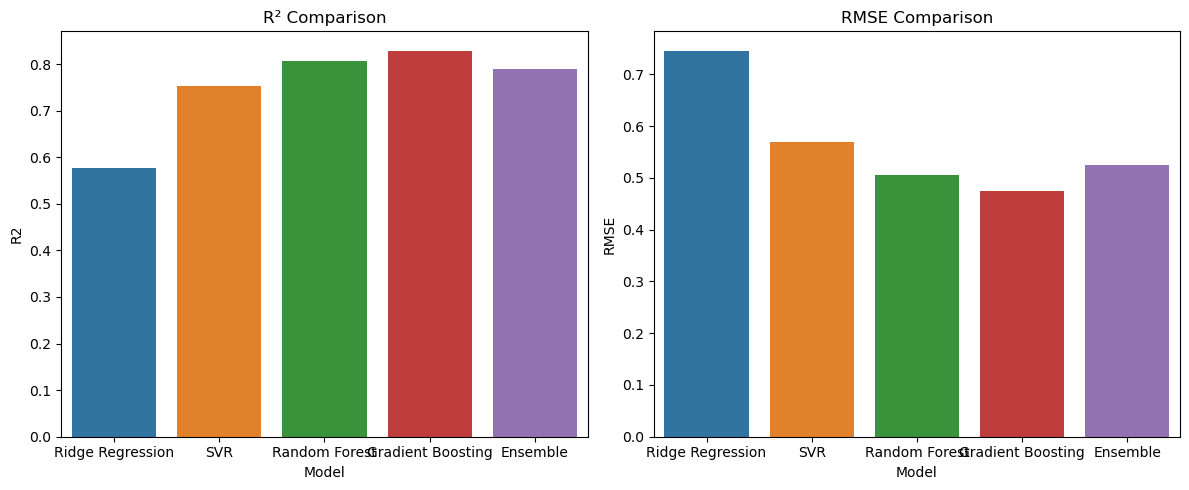

In [85]:
# ==============================================================================
# PART 8: ENSEMBLE OF TUNED MODELS
# ==============================================================================

# TODO: Create an ensemble of your best tuned models
# Use a simple averaging approach or a more sophistcated method
ensemble_models = [
    best_models["Ridge Regression"],
    best_models["SVR"],
    best_models["Random Forest"],
    best_models["Gradient Boosting"]
]

predictions = []
for model in ensemble_models:
    predictions.append(model.predict(X_test_scaled))
ensemble_pred = np.mean(predictions, axis=0)


# TODO: Evaluate the ensemble on the test set
# Compare its performance with individual models

ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
ensemble_r2 = r2_score(y_test, ensemble_pred)
comparison_results = []
for name, model in best_models.items():
    pred = model.predict(X_test_scaled)
    comparison_results.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

comparison_results.append({
    "Model": "Ensemble",
    "RMSE": ensemble_rmse,
    "R2": ensemble_r2
})

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df)

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=comparison_df, x="Model", y="R2", ax=ax[0])
ax[0].set_title("R² Comparison")
sns.barplot(data=comparison_df, x="Model", y="RMSE", ax=ax[1])
ax[1].set_title("RMSE Comparison")
plt.tight_layout()
plt.show()

In [86]:
# ==============================================================================
# SAVE BEST TUNED MODEL AS PICKLE FILE
# ==============================================================================

import pickle
from sklearn.metrics import r2_score

best_model_name = None
best_model = None
best_score = -float("inf")

for name, model in best_models.items():

    score = r2_score(
        y_test,
        model.predict(X_test_scaled)
    )

    if score > best_score:
        best_score = score
        best_model = model
        best_model_name = name

with open("best_tuned_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Best Model:", best_model_name)
print("Test R² Score:", round(best_score, 4))
print("Saved as: best_tuned_model.pkl")

Best Model: Gradient Boosting
Test R² Score: 0.8288
Saved as: best_tuned_model.pkl


In [89]:
# ==============================================================================
# PART 10: CONCLUSION AND REPORTING
# ==============================================================================

# TODO: Summarize your findings

# Which model performed best?
# Which tuning method was most efficient?
# Was the ensemble better than individual models?
# What did you learn about hyperparameter spaces?

"""
CONCLUSION

1. Best Performing Model

   In the baseline evaluation, Random Forest achieved the highest
   cross-validation performance with an R² score of 0.8042.

   After hyperparameter tuning, Gradient Boosting became the best
   performing model. Using Bayesian Optimization, it achieved the
   highest cross-validation R² score of 0.8378, outperforming all
   other models and tuning approaches.

2. Most Efficient Tuning Method

   Bayesian Optimization was the most efficient tuning method.
   It achieved the highest overall performance while intelligently
   searching the hyperparameter space instead of exhaustively
   evaluating every possible combination.

   Grid Search improved model performance but required significantly
   more computation time, especially for SVR and Random Forest.
   Random Search provided competitive results while evaluating fewer
   parameter combinations.

3. Ensemble Performance

   The ensemble model achieved an R² score of 0.7902 on the test set.

   Although ensemble learning is often used to improve prediction
   accuracy and reduce variance, in this project the ensemble did not
   outperform the best individual model. Gradient Boosting achieved
   the highest test-set R² score of 0.8288, compared to the ensemble's
   R² score of 0.7902.

4. Learning About Hyperparameter Spaces

   - Hyperparameter tuning has a significant impact on model performance.
   - Different algorithms respond differently to hyperparameter changes.
   - Grid Search guarantees an exhaustive search but can be very slow.
   - Random Search can find strong solutions with fewer evaluations.
   - Bayesian Optimization efficiently balances exploration and
     exploitation, making it suitable for large search spaces.
   - Tree-based models, particularly Gradient Boosting and Random Forest,
     benefited the most from tuning on the California Housing dataset.

Overall, this project demonstrated the importance of model selection,
hyperparameter optimization, and ensemble learning for regression tasks.
The best overall result was obtained using Gradient Boosting with
Bayesian Optimization, achieving a cross-validation R² score of 0.8378
and a test-set R² score of 0.8288.
"""

"\nCONCLUSION\n\n1. Best Performing Model\n\n   In the baseline evaluation, Random Forest achieved the highest\n   cross-validation performance with an R² score of 0.8042.\n\n   After hyperparameter tuning, Gradient Boosting became the best\n   performing model. Using Bayesian Optimization, it achieved the\n   highest cross-validation R² score of 0.8378, outperforming all\n   other models and tuning approaches.\n\n2. Most Efficient Tuning Method\n\n   Bayesian Optimization was the most efficient tuning method.\n   It achieved the highest overall performance while intelligently\n   searching the hyperparameter space instead of exhaustively\n   evaluating every possible combination.\n\n   Grid Search improved model performance but required significantly\n   more computation time, especially for SVR and Random Forest.\n   Random Search provided competitive results while evaluating fewer\n   parameter combinations.\n\n3. Ensemble Performance\n\n   The ensemble model achieved an R² score of

In [ ]:
# ==============================================================================
# REQUIREMENTS
# ==============================================================================
# 1. Your completed Jupyter notebook with all code and outputs
# 2. A brief report summarizing your findings
# 3. Visualizations comparing the different tuning methods and models
# 4. Your best tuned model saved as a pickle file